In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np
from pmdarima import auto_arima

In [2]:
df = pd.read_csv("AQI_Index_City.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   City     29531 non-null  object 
 1   Date     29531 non-null  object 
 2   PM2.5    24933 non-null  float64
 3   PM10     18391 non-null  float64
 4   NO       25949 non-null  float64
 5   NO2      25946 non-null  float64
 6   NOx      25346 non-null  float64
 7   NH3      19203 non-null  float64
 8   CO       27472 non-null  float64
 9   SO2      25677 non-null  float64
 10  O3       25509 non-null  float64
 11  Benzene  23908 non-null  float64
 12  Toluene  21490 non-null  float64
 13  Xylene   11422 non-null  float64
 14  AQI      24850 non-null  float64
dtypes: float64(13), object(2)
memory usage: 3.4+ MB


In [4]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
0,Ahmedabad,01-01-2015,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN
1,Ahmedabad,02-01-2015,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN
2,Ahmedabad,03-01-2015,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN
3,Ahmedabad,04-01-2015,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN
4,Ahmedabad,05-01-2015,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN


In [5]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [6]:
print(df.isnull().sum())

City           0
Date           0
PM2.5       4598
PM10       11140
NO          3582
NO2         3585
NOx         4185
NH3        10328
CO          2059
SO2         3854
O3          4022
Benzene     5623
Toluene     8041
Xylene     18109
AQI         4681
dtype: int64


In [7]:
df[['Benzene','Toluene','Xylene']] = df[['Benzene','Toluene','Xylene']].fillna(0)
df['BTX'] = df[['Benzene','Toluene','Xylene']].sum(axis=1)
df.drop(columns=['Benzene', 'Toluene', 'Xylene'], inplace=True)

In [8]:
df.ffill()
df.bfill()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,BTX
0,Ahmedabad,2015-01-01,73.24,141.54,0.92,18.22,17.15,26.64,0.92,27.64,133.36,209.0,0.02
1,Ahmedabad,2015-01-02,73.24,141.54,0.97,15.69,16.46,26.64,0.97,24.55,34.06,209.0,12.95
2,Ahmedabad,2015-01-03,73.24,141.54,17.40,19.30,29.70,26.64,17.40,29.07,30.70,209.0,25.45
3,Ahmedabad,2015-01-04,73.24,141.54,1.70,18.48,17.97,26.64,1.70,18.59,36.08,209.0,15.57
4,Ahmedabad,2015-01-05,73.24,141.54,22.10,21.42,37.76,26.64,22.10,39.33,39.31,209.0,28.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,41.0,15.04
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,70.0,3.33
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,68.0,0.02
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,54.0,0.00


In [9]:
cities = ['Delhi', 'Mumbai', 'Kolkata', 'Bengaluru']
df = df[df['City'].isin(cities)]

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.sort_values(by=['City', 'Date'], inplace=True)

In [12]:
df = df[df['AQI'].notnull()]

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5438 entries, 4373 to 23863
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   City    5438 non-null   object        
 1   Date    5438 non-null   datetime64[ns]
 2   PM2.5   5379 non-null   float64       
 3   PM10    5073 non-null   float64       
 4   NO      5405 non-null   float64       
 5   NO2     5405 non-null   float64       
 6   NOx     5427 non-null   float64       
 7   NH3     4860 non-null   float64       
 8   CO      5425 non-null   float64       
 9   SO2     5326 non-null   float64       
 10  O3      5231 non-null   float64       
 11  AQI     5438 non-null   float64       
 12  BTX     5438 non-null   float64       
dtypes: datetime64[ns](1), float64(11), object(1)
memory usage: 594.8+ KB


In [14]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,BTX
4373,Bengaluru,2015-03-21,48.59,NaN,3.47,27.00,18.04,28.02,3.89,1.94,52.96,91.0,218.05
4374,Bengaluru,2015-03-22,47.38,NaN,2.84,22.39,15.33,23.19,11.29,2.05,71.85,120.0,153.17
4375,Bengaluru,2015-03-23,65.65,NaN,3.10,26.35,17.45,27.76,9.95,6.30,72.84,154.0,110.65
4376,Bengaluru,2015-03-24,60.47,NaN,5.39,29.87,20.88,35.10,1.46,6.07,64.12,119.0,67.38
4377,Bengaluru,2015-03-25,62.56,NaN,3.16,23.57,16.39,27.13,10.05,4.98,82.34,232.0,44.52


In [15]:
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,BTX
count,5438,5379.000000,5073.000000,5405.000000,5405.000000,5427.000000,4860.000000,5425.000000,5326.000000,5231.000000,5438.000000,5438.000000
mean,2018-04-08 18:57:03.905847808,70.145137,147.100400,25.701029,37.960427,45.415876,29.170994,1.608053,10.828785,39.300002,163.019309,14.376276
min,2015-01-01 00:00:00,1.720000,8.220000,0.460000,2.490000,0.000000,0.150000,0.000000,0.730000,1.830000,20.000000,0.000000
25%,2016-12-28 00:00:00,25.060000,64.720000,7.500000,21.560000,19.890000,15.630000,0.720000,5.160000,23.740000,76.000000,2.150000
50%,2018-08-19 12:00:00,46.340000,108.370000,15.260000,32.900000,34.020000,26.385000,1.020000,8.730000,35.630000,116.000000,6.930000
75%,2019-07-27 18:00:00,88.040000,198.670000,31.570000,49.020000,60.245000,37.972500,1.490000,14.887500,49.655000,228.000000,19.700000
max,2020-07-01 00:00:00,685.360000,796.880000,221.030000,162.500000,293.100000,166.700000,48.070000,71.560000,257.730000,716.000000,439.280000
std,NaN,68.677540,111.655553,28.705086,22.907317,39.120693,18.143939,2.703017,7.689701,22.923623,115.178473,19.790805


In [16]:
df['City'].value_counts()

City
Delhi        1999
Bengaluru    1910
Mumbai        775
Kolkata       754
Name: count, dtype: int64

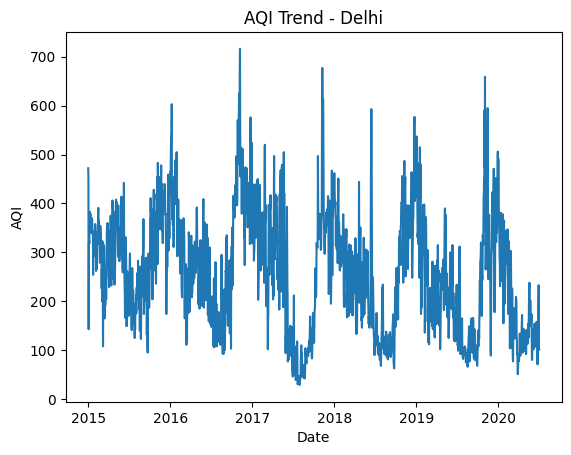

In [17]:
delhi = df[df['City'] == 'Delhi']

plt.figure()
plt.plot(delhi['Date'], delhi['AQI'])
plt.title("AQI Trend - Delhi")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.show()

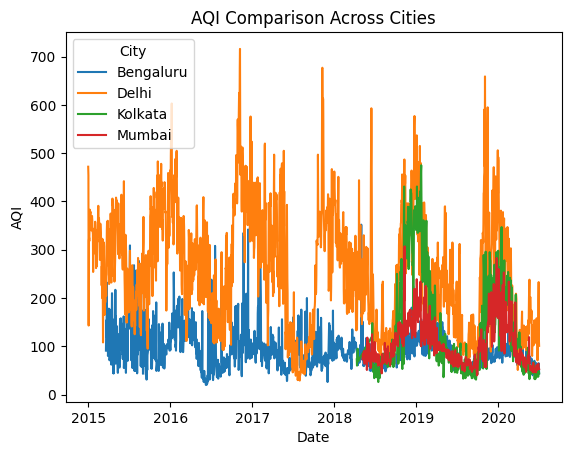

In [18]:
plt.figure()
sns.lineplot(data=df, x='Date', y='AQI', hue='City')
plt.title("AQI Comparison Across Cities")
plt.show()

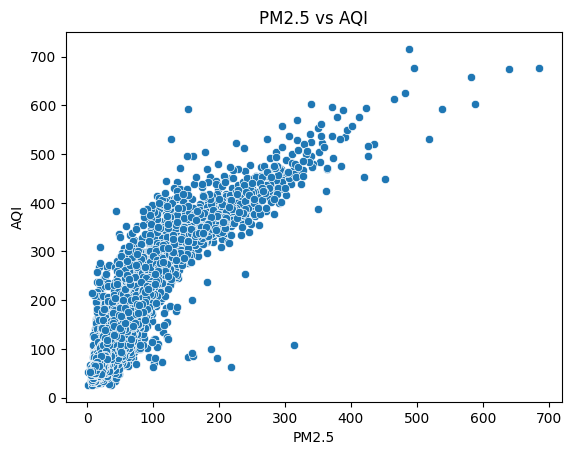

In [19]:
plt.figure()
sns.scatterplot(x=df['PM2.5'], y=df['AQI'])
plt.title("PM2.5 vs AQI")
plt.show()

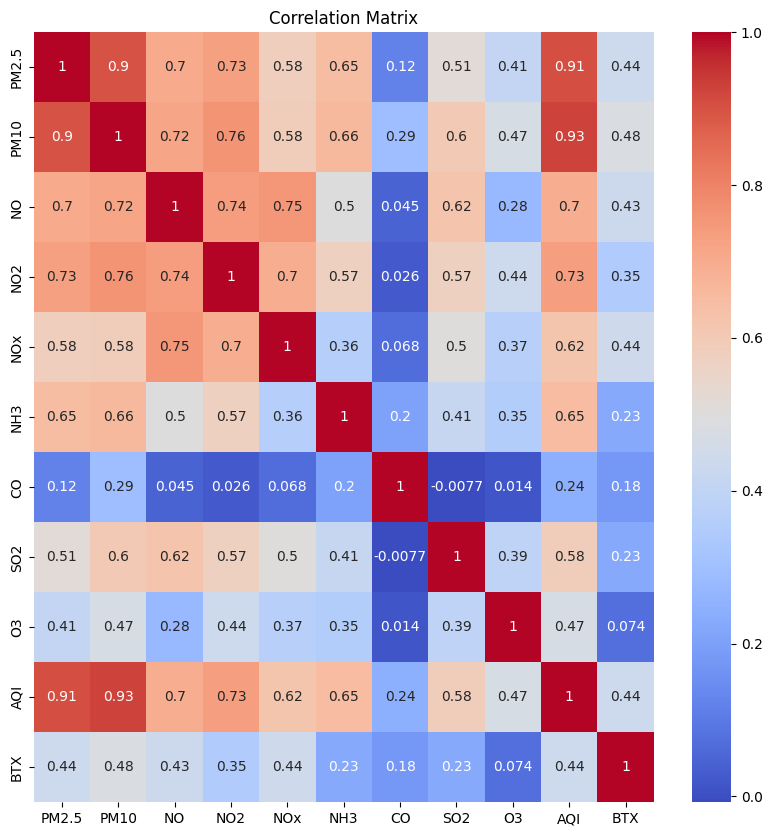

In [20]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

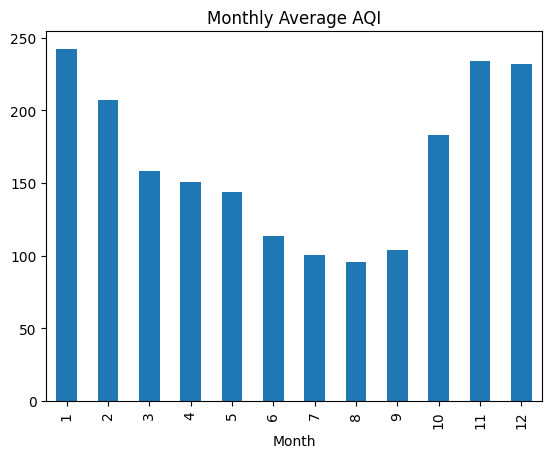

In [21]:
df['Month'] = df['Date'].dt.month

monthly_aqi = df.groupby('Month')['AQI'].mean()

plt.figure()
monthly_aqi.plot(kind='bar')
plt.title("Monthly Average AQI")
plt.show()

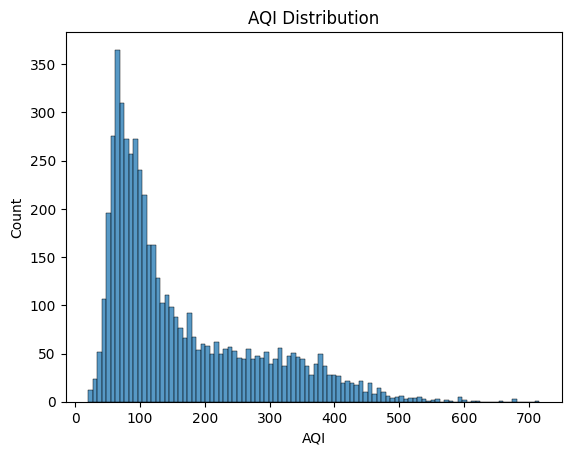

In [22]:
plt.figure()
sns.histplot(df['AQI'], bins=100)
plt.title("AQI Distribution")
plt.show()

# Final Insights from AQI Analysis

## Key Observations

1. **City-wise Pollution Levels**
   - Delhi consistently shows the highest AQI levels among all cities.
   - Bengaluru maintains relatively lower AQI, indicating better air quality.

2. **Dominant Pollutant**
   - PM2.5 and PM10 has the strongest correlation with AQI.
   - It is the primary contributor to air pollution in most cities.

3. **Seasonal Trends**
   - AQI levels peak during winter months (October–January).
   - Lower AQI levels are observed during monsoon due to pollutant dispersion.

4. **Pollutant Relationships**
   - Pollutants such as NO2, CO, and BTX show moderate correlation with AQI.
   - Indicates combined impact of vehicular and industrial emissions.

5. **Trend Analysis**
   - AQI shows fluctuating patterns over time rather than a steady increase or decrease.
   - Sudden spikes indicate episodic pollution events.

6. **Data Observations**
   - Missing values were handled using forward and backward filling.
   - Data was cleaned and structured for time series analysis.

## Conclusion

The analysis highlights that air pollution in major Indian cities is significantly influenced by seasonal variations and pollutant concentrations, especially PM2.5. Delhi emerges as the most polluted city among the selected ones, while Bengaluru maintains comparatively better air quality.

The study emphasizes the need for effective pollution control measures, especially during high-risk periods such as winter months.

## Recommendations

- Implement stricter vehicle emission regulations
- Promote use of public transport and electric vehicles
- Increase green cover in urban areas
- Monitor industrial emissions more effectively
- Issue public health advisories during high AQI periods

In [42]:
df_delhi = df[df['City'] == 'Delhi'][['Date', 'AQI']]

df_delhi['Date'] = pd.to_datetime(df_delhi['Date'])
df_delhi = df_delhi.sort_values('Date')
df_delhi.set_index('Date', inplace=True)

df_delhi = df_delhi.asfreq('D')

df_delhi['AQI'] = df_delhi['AQI'].interpolate()

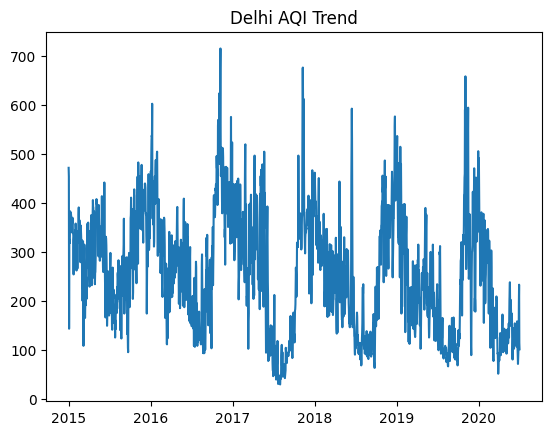

In [44]:
plt.figure()
plt.plot(df_delhi.index, df_delhi['AQI'])
plt.title("Delhi AQI Trend")
plt.show()

In [45]:
train_size = int(len(df_delhi) * 0.8)

train = df_delhi[:train_size]
test = df_delhi[train_size:]

In [46]:
auto_model = auto_arima(df_delhi['AQI'],
                        seasonal=False,
                        trace=True)

print(auto_model.order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=21398.632, Time=2.76 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=21630.884, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=21631.914, Time=0.20 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=21631.126, Time=0.73 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=21628.909, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=21396.642, Time=2.04 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=21478.335, Time=1.33 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=21452.850, Time=1.25 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=21398.631, Time=2.39 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=21416.301, Time=2.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=21401.219, Time=1.84 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=2.97 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=21394.772, Time=0.84 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=21476.379, Time=0.55 sec
 ARIMA(1,1,1)(0,0,0)[0]  

In [70]:
model_arima = ARIMA(train, order=(2,0,2))
model_arima_fit = model_arima.fit()

forecast_arima = model_arima_fit.forecast(steps=len(test))

In [71]:
df_prophet = df_delhi.reset_index()
df_prophet.columns = ['ds', 'y']

train_prophet = df_prophet[:train_size]

model_prophet = Prophet()
model_prophet.fit(train_prophet)

future = model_prophet.make_future_dataframe(periods=len(test))
forecast_prophet = model_prophet.predict(future)

pred_prophet = forecast_prophet['yhat'][-len(test):].values

21:08:42 - cmdstanpy - INFO - Chain [1] start processing
21:08:42 - cmdstanpy - INFO - Chain [1] done processing


In [72]:
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
rmse_prophet = np.sqrt(mean_squared_error(test, pred_prophet))

print("ARIMA RMSE:", rmse_arima)
print("Prophet RMSE:", rmse_prophet)

ARIMA RMSE: 126.93034939228433
Prophet RMSE: 81.27533872875416


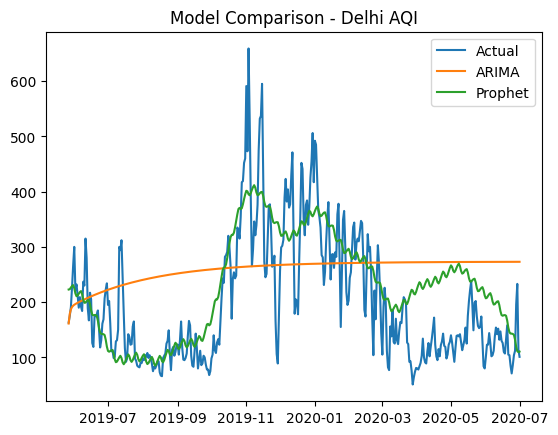

In [73]:
plt.figure()
plt.plot(test.index, test.values, label='Actual')
plt.plot(test.index, forecast_arima, label='ARIMA')
plt.plot(test.index, pred_prophet, label='Prophet')

plt.legend()
plt.title("Model Comparison - Delhi AQI")
plt.show()

In [74]:
if rmse_arima < rmse_prophet:
    print("ARIMA performs better")
else:
    print("Prophet performs better")

Prophet performs better


# Model Comparison and Evaluation

To forecast AQI levels, two time series models were implemented: **ARIMA** and **Facebook Prophet**. These models were selected due to their effectiveness in handling temporal data and their differing approaches to trend and seasonality modeling.

---

## ARIMA Model

The ARIMA (AutoRegressive Integrated Moving Average) model was applied to capture linear dependencies in the AQI time series.

- Models relationship between past values and future predictions  
- Suitable for stationary and linear data  
- Struggles with seasonality and sudden spikes  

**Observation:**  
The ARIMA model produced relatively smooth and flattened forecasts, indicating its limitation in capturing irregular variations in AQI data.

---

## Prophet Model

The Prophet model, developed by Meta, was applied as an alternative forecasting approach.

- Handles trend, seasonality, and irregular patterns  
- Robust to missing values and outliers  
- Automatically detects seasonal effects  

**Observation:**  
The Prophet model captured fluctuations and seasonal trends more effectively, producing forecasts closer to actual AQI patterns.

---

## Model Evaluation

The performance of both models was evaluated using **Root Mean Square Error (RMSE)**:

- **ARIMA RMSE:** 126.93034939228433
- **Prophet RMSE:** 81.27533872875416 

Lower RMSE indicates better model performance.

---

## Model Comparison Table

| Model    | Strengths                                      | Limitations                                      |
|----------|------------------------------------------------|--------------------------------------------------|
| ARIMA    | Simple, interpretable, good for linear trends   | Cannot capture seasonality and sudden spikes     |
| Prophet  | Captures trend, seasonality, and fluctuations   | Slightly more complex to implement               |

---

## Conclusion

Based on the evaluation, the Prophet model outperformed ARIMA in forecasting AQI levels. This is because AQI data exhibits strong seasonal and non-linear behavior, which Prophet is better equipped to model.

Therefore, Prophet was selected as the final model for AQI forecasting in this project.

---

## Key Insight

The comparison highlights that model selection depends on data characteristics. While ARIMA is effective for linear and stationary datasets, Prophet is more suitable for real-world environmental data with complex seasonal patterns.

In [76]:
cities = ['Delhi', 'Mumbai', 'Kolkata', 'Bengaluru']

all_forecasts = {}

for city in cities:
    # Prepare data
    df_city = df[df['City'] == city][['Date', 'AQI']].copy()
    df_city.columns = ['ds', 'y']
    
    # Remove missing
    df_city = df_city.dropna()
    
    # Train model
    model = Prophet()
    model.fit(df_city)
    
    # Future (10 months ≈ 300 days)
    future = model.make_future_dataframe(periods=300)
    
    forecast = model.predict(future)
    
    # Store only future part
    all_forecasts[city] = forecast[['ds', 'yhat']].tail(300)

21:15:52 - cmdstanpy - INFO - Chain [1] start processing
21:15:52 - cmdstanpy - INFO - Chain [1] done processing
21:15:53 - cmdstanpy - INFO - Chain [1] start processing
21:15:54 - cmdstanpy - INFO - Chain [1] done processing
21:15:54 - cmdstanpy - INFO - Chain [1] start processing
21:15:55 - cmdstanpy - INFO - Chain [1] done processing
21:15:55 - cmdstanpy - INFO - Chain [1] start processing
21:15:56 - cmdstanpy - INFO - Chain [1] done processing


In [77]:
combined_forecast = pd.DataFrame()

for city in cities:
    temp = all_forecasts[city].copy()
    temp['City'] = city
    combined_forecast = pd.concat([combined_forecast, temp])

print(combined_forecast.head())

             ds       yhat   City
1999 2020-07-02  64.417354  Delhi
2000 2020-07-03  64.076124  Delhi
2001 2020-07-04  56.190782  Delhi
2002 2020-07-05  48.951370  Delhi
2003 2020-07-06  43.808620  Delhi


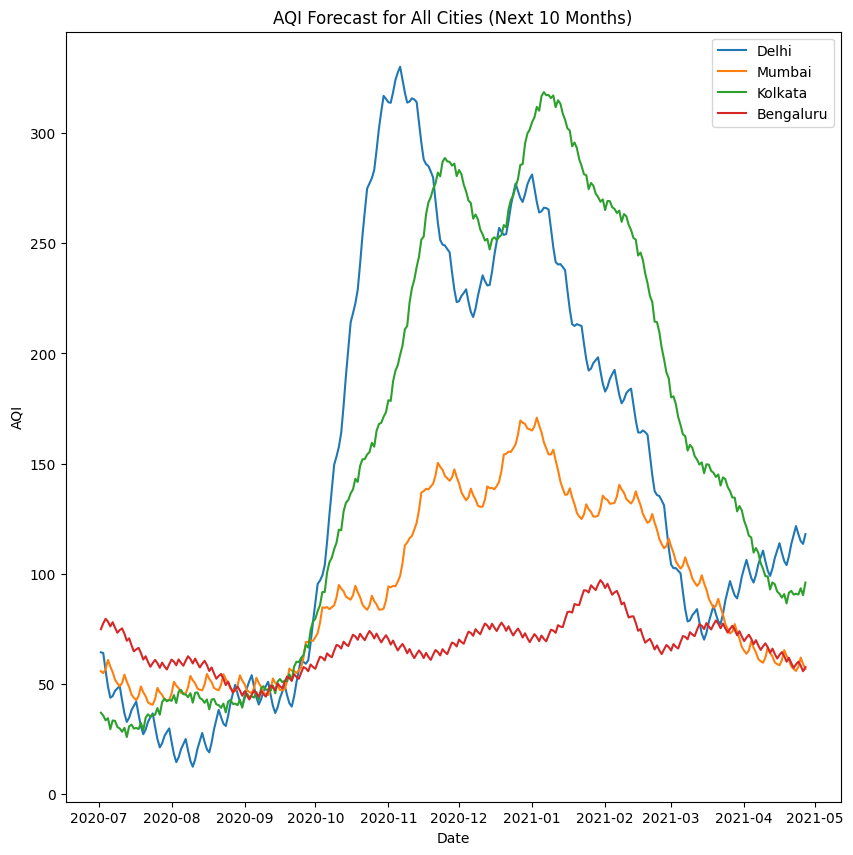

In [79]:
plt.figure(figsize = (10,10))

for city in cities:
    city_data = combined_forecast[combined_forecast['City'] == city]
    plt.plot(city_data['ds'], city_data['yhat'], label=city)

plt.legend()
plt.title("AQI Forecast for All Cities (Next 10 Months)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.show()

## Future AQI Prediction for Major Indian Cities

AQI levels for Delhi, Mumbai, Kolkata, and Bengaluru were forecasted for the next 6–10 months using the Prophet model.

### Observations

- **Delhi and Kolkata** are expected to maintain the highest AQI levels, with noticeable seasonal spikes.
- **Mumbai** shows moderate AQI levels with periodic fluctuations.
- **Bengaluru** consistently exhibits lower AQI compared to other cities.
- All cities demonstrate **seasonal patterns**, with higher AQI during winter months and lower levels during monsoon periods.

### Trend Analysis

- AQI does not show a consistent increasing or decreasing trend but fluctuates over time.
- Seasonal variation plays a major role in determining air quality.
- Pollution levels remain a concern, especially in densely populated urban regions.

### Implications

- Urban areas, especially Delhi, require stricter pollution control measures.
- Seasonal preparedness is essential to manage peak pollution periods.
- Continuous monitoring and policy intervention are necessary.

### Conclusion

The multi-city forecasting highlights that air pollution remains a persistent issue across Indian cities, with varying intensity. Seasonal trends dominate AQI behavior, and targeted measures are required for effective pollution management.